# 1. Thiết lập chung

In [1]:
# Cell 1: Import thư viện chung
import pandas as pd
import numpy as np
import os
import json
from tqdm.auto import tqdm
import warnings
import gc # Thêm Garbage Collector

In [2]:
# Cell 2: Import thư viện PyTorch cơ bản
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Bỏ qua warnings
warnings.filterwarnings('ignore')

In [3]:
# Cell 3: Thiết lập Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Cell 4: Đường dẫn (Giả định file đã được xử lý từ Notebook 01)
KAGGLE_INPUT_PATH = '/kaggle/input/tmg-processed' # Đường dẫn input
KAGGLE_WORKING_PATH = '/kaggle/working/'      # Đường dẫn output

TRAIN_PATH = os.path.join(KAGGLE_INPUT_PATH, 'train_processed.csv')
VAL_PATH = os.path.join(KAGGLE_INPUT_PATH, 'val_processed.csv')
TEST_PATH = os.path.join(KAGGLE_INPUT_PATH, 'test_processed.csv')

In [5]:
# Cell 5: Đọc file
try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)
    
    print(f"Tải {len(train_df)} mẫu train, {len(val_df)} mẫu val, {len(test_df)} mẫu test.")
except FileNotFoundError:
    print("LỖI: Không tìm thấy file ..._processed.csv. Bạn cần chạy notebook 01 trước.")
    # Dừng ở đây nếu không có data
    raise

Tải 23033 mẫu train, 3302 mẫu val, 6609 mẫu test.


In [6]:
# Cell 6: Xử lý các giá trị NaN (rất quan trọng)
train_df['text_processed'] = train_df['text_processed'].fillna("")
val_df['text_processed'] = val_df['text_processed'].fillna("")
test_df['text_processed'] = test_df['text_processed'].fillna("")

In [7]:
# Cell 7: Tách dữ liệu
# (Không cần X_train, y_train... riêng lẻ cho cách implement BERT Dataset)
print("Dataframes đã sẵn sàng.")

Dataframes đã sẵn sàng.


In [8]:
# Cell 8: (MỚI) Tạo dictionary rỗng cho baseline
# Chúng ta vẫn cần nó để Bảng 2 (Cell 20) chạy mà không lỗi
# dù nó sẽ chỉ chứa giá trị 0.0
baseline_results = {}

# 2. Bert đơn nhiệm

In [9]:
# Cell 9: Cài đặt thư viện
print("Cài đặt thư viện transformers và accelerate...")
!pip install transformers accelerate -q
print("Đã cài đặt.")

Cài đặt thư viện transformers và accelerate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take i

In [10]:
# Cell 10: Imports cho Giai đoạn 2 & 3
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    AutoModel,
    # AdamW đã bị xóa khỏi transformers, import từ torch.optim
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # <-- FIX: Import AdamW từ torch.optim

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random

print("Đã import các thư viện cho BERT và visualize (đã fix AdamW).")

Đã import các thư viện cho BERT và visualize (đã fix AdamW).


In [11]:
# Cell 11: Hằng số, Hàm hỗ trợ và Thiết lập
# 1. Hằng số
MODEL_NAME = 'vinai/phobert-base' # Backbone theo yêu cầu
MAX_LENGTH = 256                   # Max length từ pipeline
SEEDS = [42]             # 3 seeds để báo cáo mean/std
N_EPOCHS_BERT = 5                  # Số epochs (3-5 là phổ biến cho fine-tune BERT)
LR = 2e-5                          # Learning rate theo pipeline
BATCH_SIZE_BERT = 16               # Batch size theo pipeline (16 hoặc 32)

# 2. (MỚI) Đường dẫn Figures
# (Được chuyển lên đây từ phần SVM đã bị xóa)
FIGURES_PATH = os.path.join(KAGGLE_WORKING_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)
print(f"Thư mục lưu ảnh: {FIGURES_PATH}")

# 3. Hàm set_seed để đảm bảo tính tái lập (robustness)
def set_seed(seed_value):
    """Cố định random seed cho PyTorch, NumPy, và Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# 4. Hàm tính H-Score (Harmonic Mean)
def calculate_h_score(f1_s, f1_t):
    """Tính Harmonic Mean của 2 F1 scores."""
    if f1_s + f1_t == 0:
        return 0.0
    return (2 * f1_s * f1_t) / (f1_s + f1_t)

# 5. Dictionary để lưu kết quả BERT
bert_results = {}

# 6. Lấy số lượng class
N_SENT_CLASSES = train_df['sentiment'].nunique()
N_TOPIC_CLASSES = train_df['classification'].nunique()

print(f"Backbone Model: {MODEL_NAME}")
print(f"Seeds: {SEEDS}")
print(f"Số lớp Sentiment: {N_SENT_CLASSES}")
print(f"Số lớp Topic: {N_TOPIC_CLASSES}")

Thư mục lưu ảnh: /kaggle/working/figures
Backbone Model: vinai/phobert-base
Seeds: [42]
Số lớp Sentiment: 4
Số lớp Topic: 10


In [12]:
# Cell 12: 2.1. Định nghĩa PyTorch Dataset tùy chỉnh
class VietnameseSentimentTopicDataset(Dataset):
    """
    Class Dataset tùy chỉnh cho PyTorch.
    Đọc dataframe và dùng tokenizer để trả về inputs cho BERT.
    """
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.texts = dataframe['text_processed'].values
        self.sent_labels = dataframe['sentiment'].values
        self.topic_labels = dataframe['classification'].values
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        sent_label = self.sent_labels[idx]
        topic_label = self.topic_labels[idx]
        
        # Tokenize văn bản
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',      # Đệm (padding)
            truncation=True,           # Cắt (truncation)
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'sentiment_labels': torch.tensor(sent_label, dtype=torch.long),
            'topic_labels': torch.tensor(topic_label, dtype=torch.long)
        }

print("Định nghĩa class VietnameseSentimentTopicDataset thành công.")

Định nghĩa class VietnameseSentimentTopicDataset thành công.


In [13]:
# Cell 13: 2.1. Khởi tạo Tokenizer và DataLoaders
print("Đang tải Tokenizer (PhoBERT)...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tạo các instance của Dataset
train_dataset = VietnameseSentimentTopicDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = VietnameseSentimentTopicDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = VietnameseSentimentTopicDataset(test_df, tokenizer, MAX_LENGTH)

# Tạo các instance của DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)

print(f"Tạo DataLoaders thành công với Batch Size: {BATCH_SIZE_BERT}")
# Kiểm tra 1 batch
try:
    batch_sample = next(iter(train_loader))
    print(f"Kích thước input_ids: {batch_sample['input_ids'].shape}")
    print(f"Kích thước sentiment_labels: {batch_sample['sentiment_labels'].shape}")
except Exception as e:
    print(f"Lỗi khi kiểm tra DataLoader: {e}")

Đang tải Tokenizer (PhoBERT)...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tạo DataLoaders thành công với Batch Size: 16
Kích thước input_ids: torch.Size([16, 256])
Kích thước sentiment_labels: torch.Size([16])


In [14]:
# Cell 14: 2.2. Huấn luyện Model 3 - BERT Đơn nhiệm
print("============================================")
print("BẮT ĐẦU HUẤN LUYỆN MODEL 3: BERT ĐƠN NHIỆM")
print("============================================")

bert_results['single_task_sentiment'] = {}
bert_results['single_task_topic'] = {}

# 1. Định nghĩa các hàm train/eval (chúng ta sẽ tái sử dụng chúng)
def train_epoch_single(model, loader, optimizer, scheduler, device, task_key):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training Single-Task"):
        # Chuyển batch lên device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch[task_key].to(device)
        
        model.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
    return total_loss / len(loader)

def eval_epoch_single(model, loader, device, task_key):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating Single-Task"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch[task_key].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), f1, all_labels, all_preds

# 2. Vòng lặp huấn luyện chính cho 2 tác vụ
all_task_keys = [('sentiment', N_SENT_CLASSES), ('topic', N_TOPIC_CLASSES)]

for task_name, num_labels in all_task_keys:
    print(f"\n--- Bắt đầu huấn luyện Đơn nhiệm: {task_name} ---")
    task_key = f"{task_name}_labels"
    f1_seeds_test = []
    
    for seed in SEEDS:
        print(f"\n--- Chạy Seed: {seed} cho tác vụ {task_name} ---")
        set_seed(seed)
        
        # Tải model
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, 
            num_labels=num_labels
        ).to(device)
        
        # Optimizer và Scheduler
        optimizer = AdamW(model.parameters(), lr=LR)
        total_steps = len(train_loader) * N_EPOCHS_BERT
        scheduler = get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=0, # Linear warmup
            num_training_steps=total_steps
        )
        
        best_val_f1 = -1.0
        best_model_state = None
        
        for epoch in range(N_EPOCHS_BERT):
            print(f"Epoch {epoch + 1}/{N_EPOCHS_BERT}")
            
            train_loss = train_epoch_single(model, train_loader, optimizer, scheduler, device, task_key)
            val_loss, val_f1, _, _ = eval_epoch_single(model, val_loader, device, task_key)
            
            print(f"\tTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-macro: {val_f1:.4f}")
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict()
                print(f"\t -> Found new best F1! Saving model.")
        
        # Tải lại model tốt nhất
        print("Tải trọng số model tốt nhất dựa trên Validation F1.")
        model.load_state_dict(best_model_state)
        
        # Đánh giá cuối cùng trên tập Test
        print("Đánh giá trên tập Test...")
        test_loss, test_f1, _, _ = eval_epoch_single(model, test_loader, device, task_key)
        print(f"--- Seed {seed} (Test) --- F1-macro: {test_f1:.4f} ---")
        
        f1_seeds_test.append(test_f1)
        
        # Giải phóng bộ nhớ
        del model, optimizer, scheduler, best_model_state
        torch.cuda.empty_cache()
        gc.collect()

    # Lưu kết quả Mean ± Std
    mean_f1 = np.mean(f1_seeds_test)
    std_f1 = np.std(f1_seeds_test)
    bert_results[f'single_task_{task_name}']['test_f1_seeds'] = f1_seeds_test
    bert_results[f'single_task_{task_name}']['test_f1_mean'] = mean_f1
    bert_results[f'single_task_{task_name}']['test_f1_std'] = std_f1
    
    print(f"\n--- KẾT QUẢ {task_name.upper()} ĐƠN NHIỆM (Test F1) ---")
    print(f"Mean: {mean_f1:.4f} | Std: {std_f1:.4f}")

print("\n✓ Hoàn thành huấn luyện Model 3 (Đơn nhiệm).")

BẮT ĐẦU HUẤN LUYỆN MODEL 3: BERT ĐƠN NHIỆM

--- Bắt đầu huấn luyện Đơn nhiệm: sentiment ---

--- Chạy Seed: 42 cho tác vụ sentiment ---


2025-11-08 09:10:29.716895: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762593029.896176      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762593029.948344      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Training Single-Task:   0%|          | 0/1440 [00:00<?, ?it/s]

Evaluating Single-Task:   0%|          | 0/207 [00:00<?, ?it/s]

	Train Loss: 0.2934 | Val Loss: 0.6828 | Val F1-macro: 0.6378
	 -> Found new best F1! Saving model.
Tải trọng số model tốt nhất dựa trên Validation F1.
Đánh giá trên tập Test...


Evaluating Single-Task:   0%|          | 0/414 [00:00<?, ?it/s]

--- Seed 42 (Test) --- F1-macro: 0.6108 ---

--- KẾT QUẢ TOPIC ĐƠN NHIỆM (Test F1) ---
Mean: 0.6108 | Std: 0.0000

✓ Hoàn thành huấn luyện Model 3 (Đơn nhiệm).


# 3. Bert đa nhiệm

In [15]:
# Cell 15: 2.3. Định nghĩa Model 4 - Kiến trúc Đa nhiệm
class BERTMultiTask(nn.Module):
    """
    Kiến trúc BERT Đa nhiệm.
    Backbone chung + 2 MLP heads riêng biệt.
    """
    def __init__(self, backbone_model, num_sent_classes, num_topic_classes):
        super(BERTMultiTask, self).__init__()
        
        # 1. Backbone chung
        self.bert = AutoModel.from_pretrained(backbone_model)
        hidden_size = self.bert.config.hidden_size # Thường là 768
        
        # 2. Lớp Dropout chung
        self.dropout = nn.Dropout(0.1) # Dropout chuẩn của BERT
        
        # 3. Head-S (Sentiment)
        self.head_s = nn.Linear(hidden_size, num_sent_classes)
        
        # 4. Head-T (Topic)
        self.head_t = nn.Linear(hidden_size, num_topic_classes)

    def forward(self, input_ids, attention_mask):
        # Lấy output từ backbone
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Lấy embedding của [CLS] token (output[0] là last_hidden_state)
        # Kích thước: [batch_size, seq_len, hidden_size]
        # Lấy [:, 0, :] -> [batch_size, hidden_size]
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        # Áp dụng dropout
        pooled_output = self.dropout(cls_output)
        
        # Đưa qua 2 heads
        logits_s = self.head_s(pooled_output)
        logits_t = self.head_t(pooled_output)
        
        return logits_s, logits_t

print("Định nghĩa class BERTMultiTask thành công.")

Định nghĩa class BERTMultiTask thành công.


In [16]:
# Cell 16: 3.1. Huấn luyện Model 4 - BERT Đa nhiệm
print("\n============================================")
print("BẮT ĐẦU HUẤN LUYỆN MODEL 4: BERT ĐA NHIỆM")
print("============================================")

bert_results['multi_task'] = {}

# 1. Định nghĩa các hàm train/eval cho đa nhiệm
def train_epoch_multi(model, loader, optimizer, scheduler, criterion_s, criterion_t, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training Multi-Task"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_s = batch['sentiment_labels'].to(device)
        labels_t = batch['topic_labels'].to(device)
        
        model.zero_grad()
        
        logits_s, logits_t = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Tính loss (alpha=1, beta=1)
        loss_s = criterion_s(logits_s, labels_s)
        loss_t = criterion_t(logits_t, labels_t)
        loss_total = loss_s + loss_t # alpha=1, beta=1
        
        total_loss += loss_total.item()
        
        loss_total.backward()
        optimizer.step()
        scheduler.step()
        
    return total_loss / len(loader)

def eval_epoch_multi(model, loader, criterion_s, criterion_t, device):
    model.eval()
    total_loss = 0
    all_preds_s, all_labels_s = [], []
    all_preds_t, all_labels_t = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating Multi-Task"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_s = batch['sentiment_labels'].to(device)
            labels_t = batch['topic_labels'].to(device)
            
            logits_s, logits_t = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            # Loss
            loss_s = criterion_s(logits_s, labels_s)
            loss_t = criterion_t(logits_t, labels_t)
            loss_total = loss_s + loss_t
            total_loss += loss_total.item()
            
            # Thu thập preds/labels cho Sentiment
            preds_s = torch.argmax(logits_s, dim=1).cpu().numpy()
            all_preds_s.extend(preds_s)
            all_labels_s.extend(labels_s.cpu().numpy())
            
            # Thu thập preds/labels cho Topic
            preds_t = torch.argmax(logits_t, dim=1).cpu().numpy()
            all_preds_t.extend(preds_t)
            all_labels_t.extend(labels_t.cpu().numpy())
            
    # Tính F1-macro và H-Score
    f1_s = f1_score(all_labels_s, all_preds_s, average='macro')
    f1_t = f1_score(all_labels_t, all_preds_t, average='macro')
    h_score = calculate_h_score(f1_s, f1_t)
    
    # Trả về tất cả để phân tích
    return total_loss / len(loader), f1_s, f1_t, h_score, all_labels_s, all_preds_s, all_labels_t, all_preds_t

# 2. Vòng lặp huấn luyện chính
sent_f1_seeds_test = []
topic_f1_seeds_test = []
h_score_seeds_test = []

# Biến để lưu kết quả cho Confusion Matrix (từ seed đầu tiên)
cm_results = {}

for i, seed in enumerate(SEEDS):
    print(f"\n--- Chạy Seed: {seed} cho tác vụ Đa nhiệm ---")
    set_seed(seed)
    
    # Tải model
    model = BERTMultiTask(MODEL_NAME, N_SENT_CLASSES, N_TOPIC_CLASSES).to(device)
    
    # Optimizer và Scheduler
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * N_EPOCHS_BERT
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=0, 
        num_training_steps=total_steps
    )
    
    # Hàm Loss (theo yêu cầu)
    criterion_s = nn.CrossEntropyLoss().to(device)
    criterion_t = nn.CrossEntropyLoss().to(device)
    
    best_val_h_score = -1.0
    best_model_state = None
    
    for epoch in range(N_EPOCHS_BERT):
        print(f"Epoch {epoch + 1}/{N_EPOCHS_BERT}")
        
        train_loss = train_epoch_multi(model, train_loader, optimizer, scheduler, criterion_s, criterion_t, device)
        val_loss, val_f1_s, val_f1_t, val_h, _, _, _, _ = eval_epoch_multi(model, val_loader, criterion_s, criterion_t, device)
        
        print(f"\tTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"\tVal F1-S: {val_f1_s:.4f} | Val F1-T: {val_f1_t:.4f} | Val H-Score: {val_h:.4f}")
        
        if val_h > best_val_h_score:
            best_val_h_score = val_h
            best_model_state = model.state_dict()
            print(f"\t -> Found new best H-Score! Saving model.")
            
    # Tải lại model tốt nhất (dựa trên Val H-Score)
    print("Tải trọng số model tốt nhất dựa trên Validation H-Score.")
    model.load_state_dict(best_model_state)
    
    # Đánh giá cuối cùng trên tập Test
    print("Đánh giá trên tập Test...")
    test_loss, test_f1_s, test_f1_t, test_h, lbl_s, pred_s, lbl_t, pred_t = eval_epoch_multi(
        model, test_loader, criterion_s, criterion_t, device
    )
    
    print(f"--- Seed {seed} (Test) ---")
    print(f"\tTest F1-S: {test_f1_s:.4f} | Test F1-T: {test_f1_t:.4f} | Test H-Score: {test_h:.4f}")
    
    # Lưu kết quả
    sent_f1_seeds_test.append(test_f1_s)
    topic_f1_seeds_test.append(test_f1_t)
    h_score_seeds_test.append(test_h)
    
    # (Stage 3.3) Lưu kết quả của seed đầu tiên để vẽ CM
    if i == 0:
        cm_results['labels_s'] = lbl_s
        cm_results['preds_s'] = pred_s
        cm_results['labels_t'] = lbl_t
        cm_results['preds_t'] = pred_t
        print(f"Đã lưu kết quả dự đoán (preds) của seed {seed} để vẽ Confusion Matrix.")

    # Giải phóng bộ nhớ
    del model, optimizer, scheduler, best_model_state
    torch.cuda.empty_cache()
    gc.collect()

# Lưu kết quả Mean ± Std
bert_results['multi_task']['test_f1_s_mean'] = np.mean(sent_f1_seeds_test)
bert_results['multi_task']['test_f1_s_std'] = np.std(sent_f1_seeds_test)
bert_results['multi_task']['test_f1_t_mean'] = np.mean(topic_f1_seeds_test)
bert_results['multi_task']['test_f1_t_std'] = np.std(topic_f1_seeds_test)
bert_results['multi_task']['test_h_score_mean'] = np.mean(h_score_seeds_test)
bert_results['multi_task']['test_h_score_std'] = np.std(h_score_seeds_test)

print("\n--- KẾT QUẢ ĐA NHIỆM (Test) ---")
print(f"F1-Sentiment: {bert_results['multi_task']['test_f1_s_mean']:.4f} ± {bert_results['multi_task']['test_f1_s_std']:.4f}")
print(f"F1-Topic:     {bert_results['multi_task']['test_f1_t_mean']:.4f} ± {bert_results['multi_task']['test_f1_t_std']:.4f}")
print(f"H-Score:      {bert_results['multi_task']['test_h_score_mean']:.4f} ± {bert_results['multi_task']['test_h_score_std']:.4f}")

print("\n✓ Hoàn thành huấn luyện Model 4 (Đa nhiệm).")


BẮT ĐẦU HUẤN LUYỆN MODEL 4: BERT ĐA NHIỆM

--- Chạy Seed: 42 cho tác vụ Đa nhiệm ---
Epoch 1/5


Training Multi-Task:   0%|          | 0/1440 [00:00<?, ?it/s]

Evaluating Multi-Task:   0%|          | 0/207 [00:00<?, ?it/s]

	Train Loss: 1.5311 | Val Loss: 1.2174
	Val F1-S: 0.6982 | Val F1-T: 0.5408 | Val H-Score: 0.6095
	 -> Found new best H-Score! Saving model.
Epoch 2/5


Training Multi-Task:   0%|          | 0/1440 [00:00<?, ?it/s]

...

Training Multi-Task:   0%|          | 0/1440 [00:00<?, ?it/s]

Evaluating Multi-Task:   0%|          | 0/207 [00:00<?, ?it/s]

	Train Loss: 0.6105 | Val Loss: 1.1574
	Val F1-S: 0.7657 | Val F1-T: 0.6235 | Val H-Score: 0.6873
Tải trọng số model tốt nhất dựa trên Validation H-Score.
Đánh giá trên tập Test...


Evaluating Multi-Task:   0%|          | 0/414 [00:00<?, ?it/s]

--- Seed 42 (Test) ---
	Test F1-S: 0.7711 | Test F1-T: 0.6128 | Test H-Score: 0.6829
Đã lưu kết quả dự đoán (preds) của seed 42 để vẽ Confusion Matrix.

--- KẾT QUẢ ĐA NHIỆM (Test) ---
F1-Sentiment: 0.7711 ± 0.0000
F1-Topic:     0.6128 ± 0.0000
H-Score:      0.6829 ± 0.0000

✓ Hoàn thành huấn luyện Model 4 (Đa nhiệm).


# 4. Bảng so sánh kết quả

In [17]:
# Cell 17: 3.2. Tạo Bảng so sánh chính (Giống Tab 2)
print("\n============================================")
print("BẢNG 2: TỔNG KẾT KẾT QUẢ (Test F1-macro)")
print("============================================")

# 1. Lấy kết quả SVM và BiLSTM (sẽ là 0.0 vì chúng ta đã bỏ qua)
svm_s_f1 = baseline_results.get('svm_sentiment_test', 0.0)
svm_t_f1 = baseline_results.get('svm_topic_test', 0.0)
svm_h = calculate_h_score(svm_s_f1, svm_t_f1)

lstm_s_f1 = baseline_results.get('bilstm_sentiment_test', 0.0)
lstm_t_f1 = baseline_results.get('bilstm_topic_test', 0.0)
lstm_h = calculate_h_score(lstm_s_f1, lstm_t_f1)

# 2. Lấy kết quả BERT Đơn nhiệm
bert_s_mean = bert_results['single_task_sentiment']['test_f1_mean']
bert_s_std = bert_results['single_task_sentiment']['test_f1_std']
bert_t_mean = bert_results['single_task_topic']['test_f1_mean']
bert_t_std = bert_results['single_task_topic']['test_f1_std']
bert_single_h = calculate_h_score(bert_s_mean, bert_t_mean) # H-score của mean

# 3. Lấy kết quả BERT Đa nhiệm
bert_multi_s_mean = bert_results['multi_task']['test_f1_s_mean']
bert_multi_s_std = bert_results['multi_task']['test_f1_s_std']
bert_multi_t_mean = bert_results['multi_task']['test_f1_t_mean']
bert_multi_t_std = bert_results['multi_task']['test_f1_t_std']
bert_multi_h_mean = bert_results['multi_task']['test_h_score_mean']
bert_multi_h_std = bert_results['multi_task']['test_h_score_std']

# 4. Tạo dict dữ liệu
report_data = {
    "TF-IDF + SVM": {
        "F1-Sentiment": f"{svm_s_f1:.4f}",
        "F1-Topic": f"{svm_t_f1:.4f}",
        "H-Score": f"{svm_h:.4f}"
    },
    "BiLSTM": {
        "F1-Sentiment": f"{lstm_s_f1:.4f}",
        "F1-Topic": f"{lstm_t_f1:.4f}",
        "H-Score": f"{lstm_h:.4f}"
    },
    "BERT Đơn nhiệm": {
        "F1-Sentiment": f"{bert_s_mean:.4f} ± {bert_s_std:.4f}",
        "F1-Topic": f"{bert_t_mean:.4f} ± {bert_t_std:.4f}",
        "H-Score": f"{bert_single_h:.4f} (từ mean)"
    },
    "BERT Đa nhiệm": {
        "F1-Sentiment": f"{bert_multi_s_mean:.4f} ± {bert_multi_s_std:.4f}",
        "F1-Topic": f"{bert_multi_t_mean:.4f} ± {bert_multi_t_std:.4f}",
        "H-Score": f"{bert_multi_h_mean:.4f} ± {bert_multi_h_std:.4f}"
    }
}

# 5. In bảng (sử dụng Markdown cho đẹp)
final_report_df = pd.DataFrame.from_dict(report_data, orient='index')
print(final_report_df.to_markdown())

# 6. Lưu kết quả BERT metrics
BERT_METRICS_PATH = os.path.join(KAGGLE_WORKING_PATH, 'bert_metrics.json')
with open(BERT_METRICS_PATH, 'w') as f:
    json.dump(bert_results, f, indent=2)
    
print(f"\n✓ Kết quả BERT metrics đã được lưu vào: {BERT_METRICS_PATH}")


BẢNG 2: TỔNG KẾT KẾT QUẢ (Test F1-macro)
|                | F1-Sentiment    | F1-Topic        | H-Score          |
|:---------------|:----------------|:----------------|:-----------------|
| TF-IDF + SVM   | 0.0000          | 0.0000          | 0.0000           |
| BiLSTM         | 0.0000          | 0.0000          | 0.0000           |
| BERT Đơn nhiệm | 0.7778 ± 0.0000 | 0.6108 ± 0.0000 | 0.6843 (từ mean) |
| BERT Đa nhiệm  | 0.7711 ± 0.0000 | 0.6128 ± 0.0000 | 0.6829 ± 0.0000  |

✓ Kết quả BERT metrics đã được lưu vào: /kaggle/working/bert_metrics.json



3.3. PHÂN TÍCH KẾT QUẢ (Model Đa nhiệm - Seed 42)


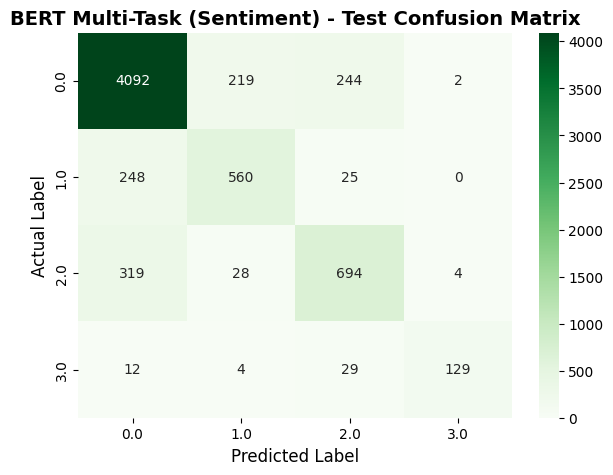

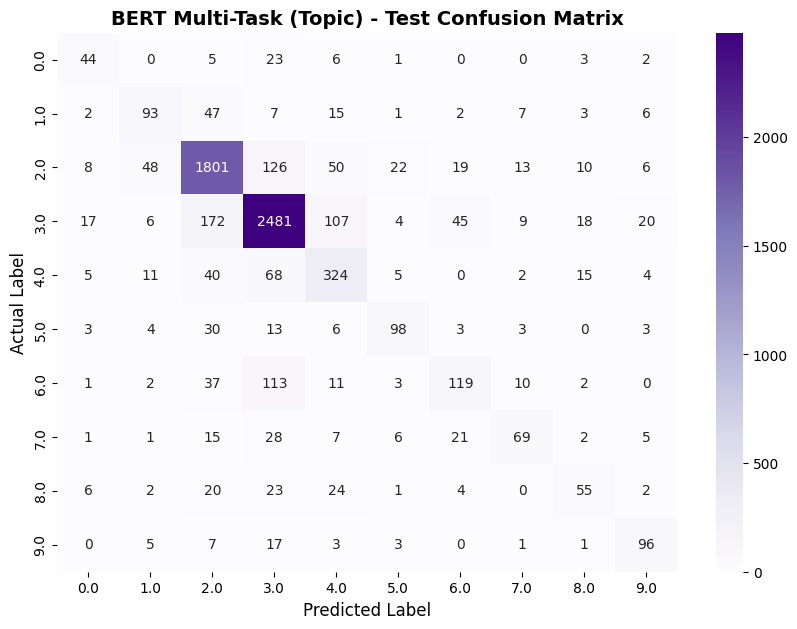


--- Phân tích lỗi (Error Analysis) ---
Tổng số mẫu dự đoán sai (ít nhất 1 tác vụ): 2292 / 6609

--- 20 ví dụ dự đoán sai (text_processed) ---
| text_processed                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |   sentiment |   pred_sent | is_wrong_sent   |   classification |   pred_topic | is_wrong_topic   |
|:-----------------------

In [18]:
# Cell 18: 3.3. Ma trận nhầm lẫn (Confusion Matrix)
print("\n============================================")
print("3.3. PHÂN TÍCH KẾT QUẢ (Model Đa nhiệm - Seed 42)")
print("============================================")

# Lấy nhãn (giống như trong template)
class_labels_sent = sorted(test_df['sentiment'].unique())
class_labels_topic = sorted(test_df['classification'].unique())

# --- 1. Vẽ CM cho Sentiment ---
cm_sent = confusion_matrix(cm_results['labels_s'], cm_results['preds_s'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels_sent, yticklabels=class_labels_sent)
plt.title('BERT Multi-Task (Sentiment) - Test Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.savefig(os.path.join(FIGURES_PATH, 'bert_multi_sentiment_test_cm.png'), dpi=300)
plt.show()

# --- 2. Vẽ CM cho Topic ---
cm_topic = confusion_matrix(cm_results['labels_t'], cm_results['preds_t'])
plt.figure(figsize=(10, 7))
sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_labels_topic, yticklabels=class_labels_topic)
plt.title('BERT Multi-Task (Topic) - Test Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.savefig(os.path.join(FIGURES_PATH, 'bert_multi_topic_test_cm.png'), dpi=300)
plt.show()

# Cell 19: 3.3. Phân tích lỗi (Error Analysis)
print("\n--- Phân tích lỗi (Error Analysis) ---")

# Tạo một DataFrame phân tích từ tập test
test_analysis_df = test_df.copy()
test_analysis_df['pred_sent'] = cm_results['preds_s']
test_analysis_df['pred_topic'] = cm_results['preds_t']

# Kiểm tra lỗi
test_analysis_df['is_wrong_sent'] = test_analysis_df['sentiment'] != test_analysis_df['pred_sent']
test_analysis_df['is_wrong_topic'] = test_analysis_df['classification'] != test_analysis_df['pred_topic']
test_analysis_df['is_wrong_any'] = test_analysis_df['is_wrong_sent'] | test_analysis_df['is_wrong_topic']

# Lọc ra các dự đoán sai
wrong_predictions_df = test_analysis_df[test_analysis_df['is_wrong_any']]

print(f"Tổng số mẫu dự đoán sai (ít nhất 1 tác vụ): {len(wrong_predictions_df)} / {len(test_analysis_df)}")

# In ra 20 ví dụ sai
print("\n--- 20 ví dụ dự đoán sai (text_processed) ---")
pd.set_option('display.max_colwidth', 200) # Để xem text rõ hơn
print(wrong_predictions_df[[
    'text_processed', 
    'sentiment', 'pred_sent', 'is_wrong_sent',
    'classification', 'pred_topic', 'is_wrong_topic'
]].head(20).to_markdown(index=False))

print("\n✓ HOÀN THÀNH TOÀN BỘ GIAI ĐOẠN BERT.")